# Omega Profile Comparison — BEACH vs ERA5 vs M4 Blend

Three side-by-side panels per circle:
- **Left** — Raw BEACH L4 omega (unbinned, full altitude grid)
- **Middle** — ERA5 omega at nearest time & location (discrete pressure levels)
- **Right** — M4 cosine-blend profile (BEACH blended → ERA5, full column to ~20 hPa)

Use the dropdown or set `CIRCLE` manually to switch circles.

In [9]:
import sys, warnings
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display
import xarray as xr

from scripts.mse_budget import load_dataset
from scripts.era5_extension import load_era5_omega, blend_beach_era5, match_era5_to_circle

print('Loading BEACH L4 ...')
ds = load_dataset()
print('Loading ERA5 omega ...')
era5_ds = load_era5_omega()
print('Computing M4 blend ...')
ds_ext = blend_beach_era5(ds, era5_ds=era5_ds)
print('Ready.')

Loading BEACH L4 ...
Loading ERA5 omega ...
Computing M4 blend ...
Ready.


In [10]:
# ── Pre-extract arrays ────────────────────────────────────────────────────────
omega_b  = ds['omega'].values.astype(float)       # (circle, altitude)  BEACH raw
p_b      = ds['p_mean'].values.astype(float)      # (circle, altitude)  Pa
omega_m4 = ds_ext['omega_ext'].values             # (circle, ext_level) M4 blend
p_m4     = ds_ext['p_ext'].values                 # (circle, ext_level) Pa

cats     = ds['category_plane'].values if 'category_plane' in ds else ds['category_avg'].values
circles  = ds['circle'].values
ctimes   = ds['circle_time'].values
clats    = ds['circle_lat'].values
clons    = ds['circle_lon'].values

# p_top per circle (omega/p valid)
p_tops = []
for i in range(ds.sizes['circle']):
    valid = np.isfinite(omega_b[i]) & np.isfinite(p_b[i])
    p_tops.append(float(p_b[i, np.where(valid)[0][-1]]) if valid.sum() > 0 else np.nan)
p_tops = np.array(p_tops)

COLOR = {'Top-Heavy': '#d62728', 'Top-Heavy (Fully Ascending)': '#d62728',
         'Bottom-Heavy': '#1f77b4', 'Bottom-Heavy (Fully Ascending)': '#1f77b4',
         'Inactive / Suppressed': '#888888'}

BLEND_WIDTH_PA = 5000.0

print(f'Dataset: {ds.sizes["circle"]} circles, {ds.sizes["altitude"]} altitude levels')
print(f'p_top range: {np.nanmin(p_tops)/100:.1f} – {np.nanmax(p_tops)/100:.1f} hPa')

Dataset: 89 circles, 1460 altitude levels
p_top range: 142.5 – 245.9 hPa


In [11]:
# ── Core plot function ────────────────────────────────────────────────────────
def plot_circle(circle_id):
    """Plot 3-panel omega comparison for one circle."""
    ci = int(np.where(circles == circle_id)[0][0])
    cat   = cats[ci]
    col   = COLOR.get(cat, '#888888')
    ctime = str(ctimes[ci])[:16]
    p_top = p_tops[ci]
    p_blend_bot = p_top + BLEND_WIDTH_PA

    # ── BEACH (raw) ───────────────────────────────────────────────────────────
    valid_b = np.isfinite(omega_b[ci]) & np.isfinite(p_b[ci])
    p_beach = p_b[ci, valid_b]
    o_beach = omega_b[ci, valid_b]

    # ── ERA5 (discrete levels) ────────────────────────────────────────────────
    try:
        om_e, p_e, t_e, _ = match_era5_to_circle(
            era5_ds, float(clats[ci]), float(clons[ci]), ctimes[ci]
        )
        sort_desc = np.argsort(p_e)[::-1]
        p_era5    = p_e[sort_desc]
        o_era5    = om_e[sort_desc]
        has_era5  = True
    except Exception as e:
        has_era5 = False
        print(f'ERA5 match failed: {e}')

    # ── M4 blend ──────────────────────────────────────────────────────────────
    valid_m = np.isfinite(p_m4[ci]) & np.isfinite(omega_m4[ci])
    idx_m   = np.where(valid_m)[0]
    order   = idx_m[np.argsort(p_m4[ci, idx_m])[::-1]]
    p_blend = p_m4[ci, order]
    o_blend = omega_m4[ci, order]

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 9), sharey=True)
    fig.suptitle(
        f'Circle {circle_id}  |  {cat}  |  {ctime} UTC\n'
        f'Lat={clats[ci]:.2f}°N  Lon={clons[ci]:.2f}°E  '
        f'p_top={p_top/100:.1f} hPa  blend zone={p_top/100:.0f}–{p_blend_bot/100:.0f} hPa',
        fontsize=12, fontweight='bold', color=col
    )

    xlim = (-1.0, 0.6)
    ylim = (105000, 2000)

    # ── Helper: shade blend zone ──────────────────────────────────────────────
    def _shade_blend(ax):
        ax.axhspan(p_top, p_blend_bot, alpha=0.10, color='orange',
                   label=f'Blend zone ({p_top/100:.0f}–{p_blend_bot/100:.0f} hPa)')
        ax.axhline(p_top,       color='green',  lw=1.2, ls='--',
                   label=f'BEACH top  {p_top/100:.1f} hPa')
        ax.axhline(p_blend_bot, color='orange', lw=1.0, ls=':',
                   label=f'Blend bot  {p_blend_bot/100:.1f} hPa')

    # ── Panel 1: Raw BEACH ────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(o_beach, p_beach, color=col, lw=1.8, label='Raw BEACH')
    _shade_blend(ax)
    ax.axvline(0, color='black', lw=0.7, ls='--', alpha=0.5)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel('ω  (Pa s⁻¹)', fontsize=10)
    ax.set_ylabel('Pressure  (Pa)', fontsize=10)
    ax.set_title('① Raw BEACH L4', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, alpha=0.25)

    # ── Panel 2: ERA5 ─────────────────────────────────────────────────────────
    ax = axes[1]
    if has_era5:
        ax.plot(o_era5, p_era5, color='darkorange', lw=2.0,
                marker='o', ms=5, label='ERA5 (discrete levels)')
    _shade_blend(ax)
    ax.axvline(0, color='black', lw=0.7, ls='--', alpha=0.5)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel('ω  (Pa s⁻¹)', fontsize=10)
    ax.set_title('② ERA5  (nearest time, ±2° box mean)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, alpha=0.25)

    # ── Panel 3: M4 Blend ─────────────────────────────────────────────────────
    ax = axes[2]
    # Colour the line by region: BEACH portion vs ERA5 extension
    beach_mask_m4 = p_blend >= p_top
    era5_mask_m4  = p_blend <  p_top
    if beach_mask_m4.sum() > 1:
        ax.plot(o_blend[beach_mask_m4], p_blend[beach_mask_m4],
                color=col, lw=2.0, label='BEACH (blended at top)')
    if era5_mask_m4.sum() > 1:
        ax.plot(o_blend[era5_mask_m4], p_blend[era5_mask_m4],
                color='darkorange', lw=2.0, ls='-', label='ERA5 extension')
    # Overlay raw BEACH faint for reference
    ax.plot(o_beach, p_beach, color=col, lw=0.7, ls='--', alpha=0.35, label='Raw BEACH (ref)')
    _shade_blend(ax)
    ax.axvline(0, color='black', lw=0.7, ls='--', alpha=0.5)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel('ω  (Pa s⁻¹)', fontsize=10)
    ax.set_title('③ M4 Cosine Blend + ERA5 Extension', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

In [12]:
# ── Interactive dropdown ──────────────────────────────────────────────────────
# Option labels show: circle id, category, p_top, klaster
def _klaster(pt):
    if pt < 20000: return 'A'
    if pt < 22000: return 'B'
    return 'C ⚠️'

options = [
    (f"Circle {c:3d} │ {cat[:4]} │ p_top={pt/100:.0f} hPa │ Klaster {_klaster(pt)}", int(c))
    for c, cat, pt in zip(circles, cats, p_tops)
    if np.isfinite(pt)
]

dropdown = widgets.Dropdown(
    options=options,
    value=int(circles[0]),
    description='Circle:',
    layout=widgets.Layout(width='520px'),
    style={'description_width': '60px'},
)

out = widgets.Output()

def _on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        out.clear_output(wait=True)
        with out:
            plot_circle(change['new'])

dropdown.observe(_on_change)
display(dropdown, out)

# Draw initial plot
with out:
    plot_circle(int(circles[0]))

Dropdown(description='Circle:', layout=Layout(width='520px'), options=(('Circle   0 │ Inac │ p_top=168 hPa │ K…

Output()

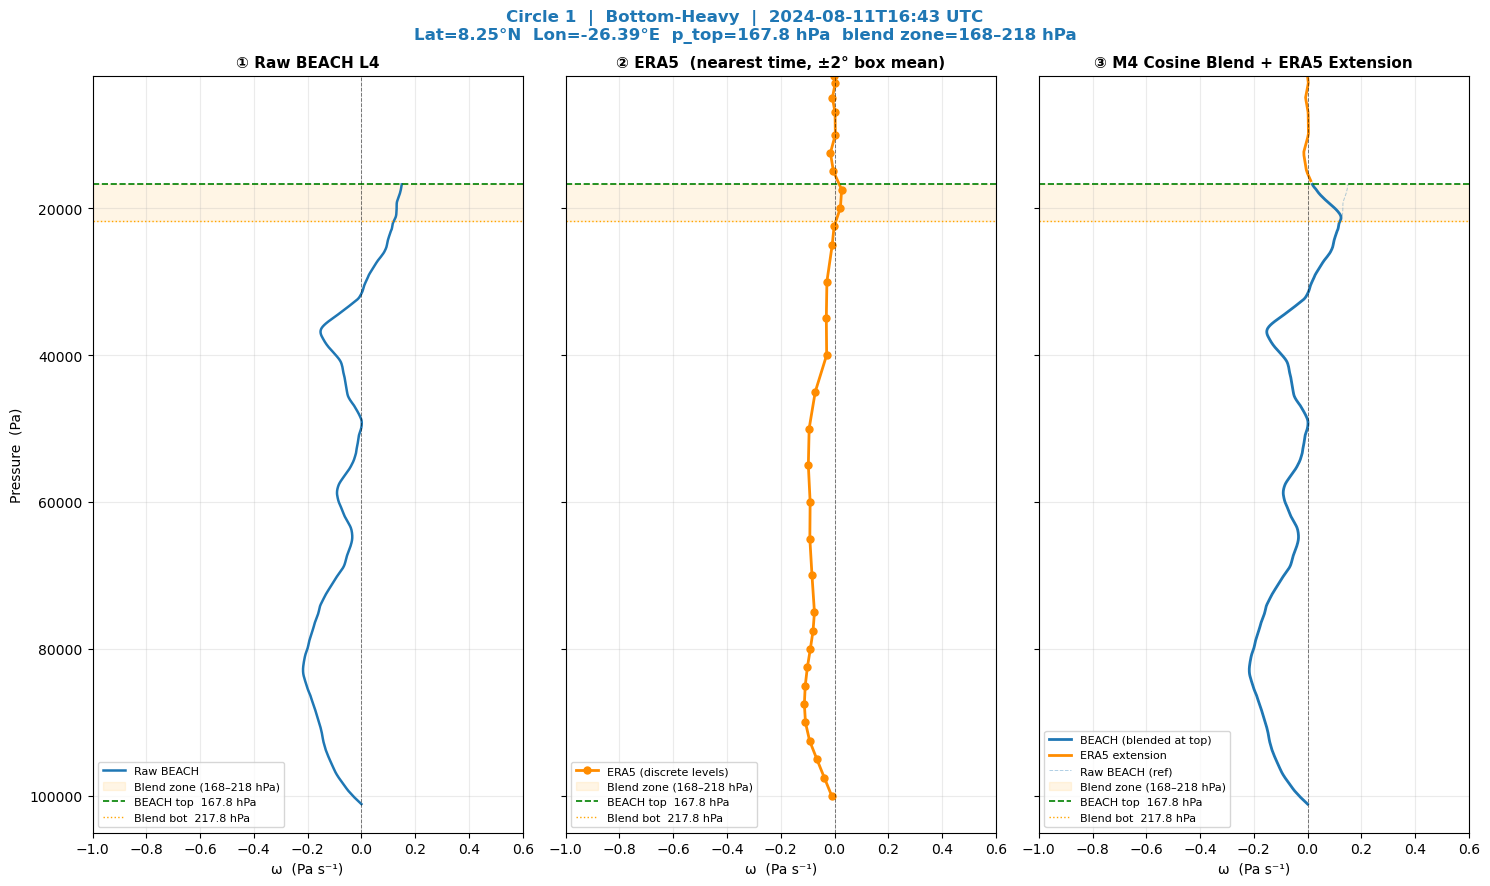

In [13]:
# ── Manual mode: set circle number directly then run this cell ───────────────
# Useful if dropdown doesn't render (e.g. non-interactive kernel)

CIRCLE = 1   # ← ganti nomor circle di sini

plot_circle(CIRCLE)

Bottom-Heavy: 28 circles


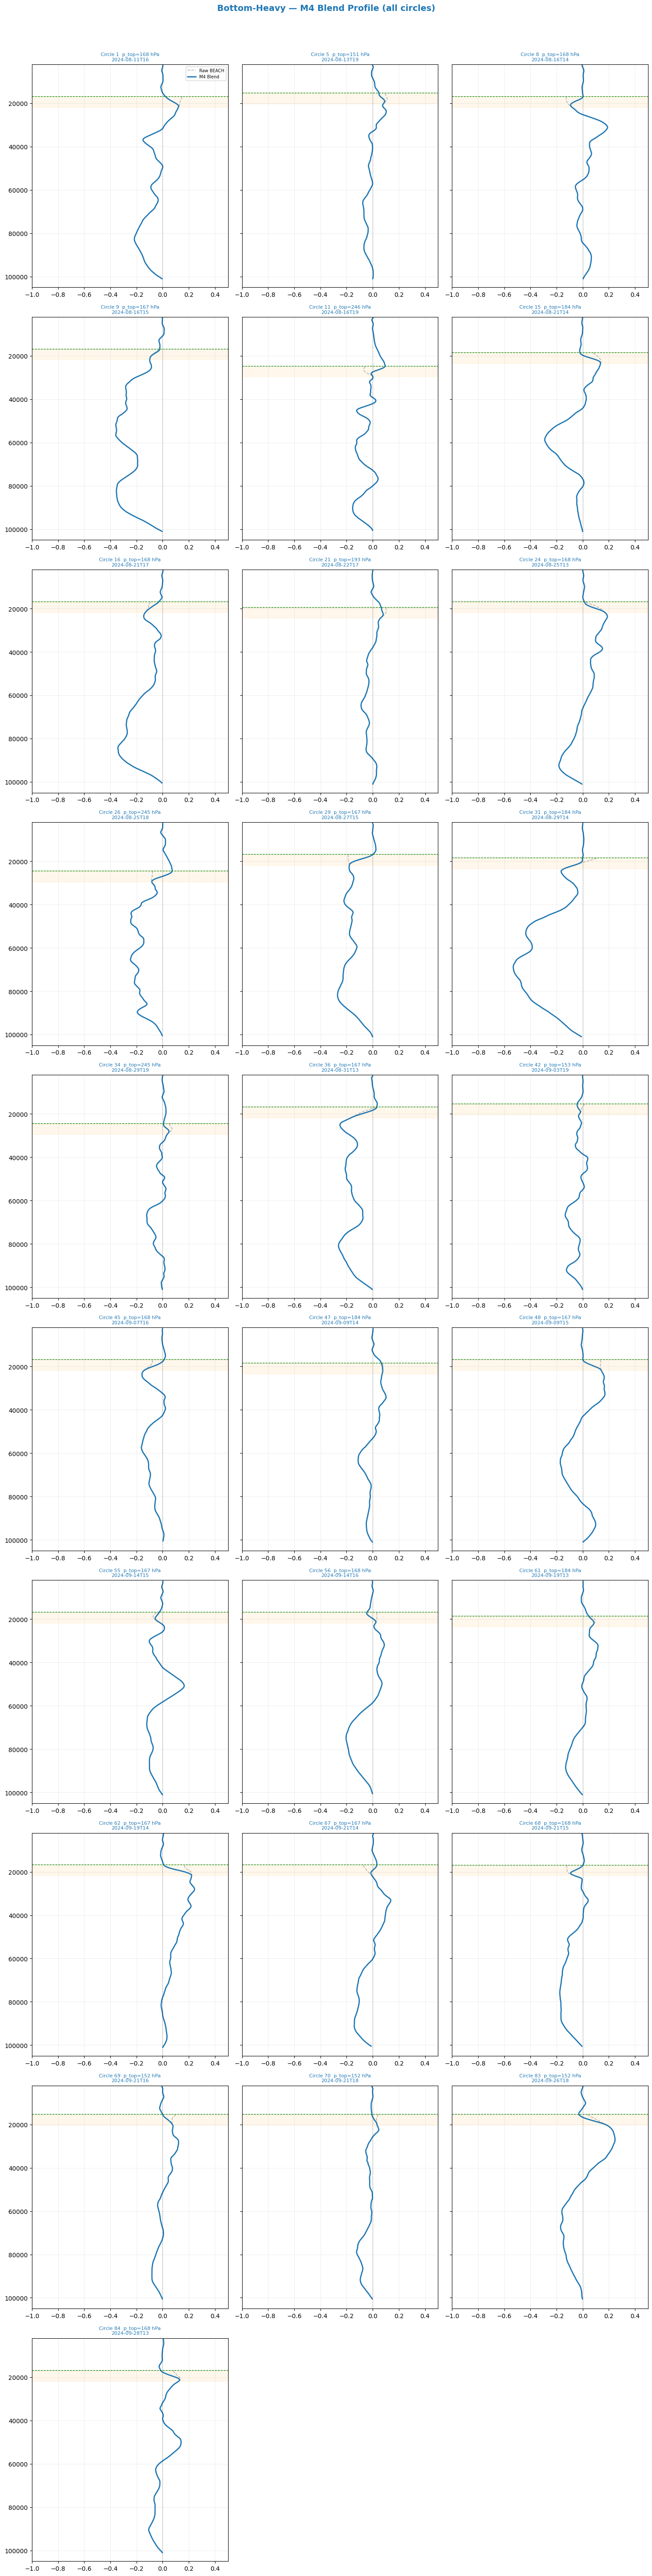

In [14]:
# ── Plot semua circle dalam satu kategori (grid) ──────────────────────────────
# Jalankan cell ini untuk membuat grid semua circles dari satu kategori

CATEGORY = 'Bottom-Heavy'   # ← ganti: 'Top-Heavy', 'Bottom-Heavy', 'Inactive / Suppressed'
SAVE_PNG = False            # ← True untuk simpan ke outputs/figures/

cat_circles = [
    (i, int(c)) for i, (c, cat) in enumerate(zip(circles, cats))
    if cat.startswith(CATEGORY.split()[0])
]
print(f'{CATEGORY}: {len(cat_circles)} circles')

ncols = 3
nrows = int(np.ceil(len(cat_circles) / ncols))
col   = '#d62728' if 'Top' in CATEGORY else ('#1f77b4' if 'Bottom' in CATEGORY else '#888888')

fig, axes_grid = plt.subplots(nrows, ncols, figsize=(5*ncols, 6*nrows), sharey=True)
fig.suptitle(f'{CATEGORY} — M4 Blend Profile (all circles)', fontsize=14,
             fontweight='bold', color=col)

axes_flat = np.atleast_1d(axes_grid).ravel()
BIN_PA    = 500.0
P_COMMON  = np.arange(2000, 105500, BIN_PA)

def _bin(omega, p):
    valid = np.isfinite(omega) & np.isfinite(p)
    if valid.sum() < 3: return np.full(len(P_COMMON), np.nan)
    pv, ov = p[valid], omega[valid]
    edges  = np.arange(np.floor(pv.min()/BIN_PA)*BIN_PA,
                       np.ceil(pv.max()/BIN_PA)*BIN_PA + BIN_PA, BIN_PA)
    osum, _ = np.histogram(pv, bins=edges, weights=ov)
    cnt,  _ = np.histogram(pv, bins=edges)
    pctr    = edges[:-1] + BIN_PA/2
    res     = np.where(cnt>0, osum/cnt, np.nan)
    has     = cnt > 0
    return np.interp(P_COMMON, pctr[has], res[has], left=np.nan, right=np.nan)

for ax_idx, (ci, cid) in enumerate(cat_circles):
    ax = axes_flat[ax_idx]
    pt = p_tops[ci]

    ob_raw = _bin(omega_b[ci],  p_b[ci])
    ob_m4  = _bin(omega_m4[ci], p_m4[ci])

    ax.plot(ob_raw[np.isfinite(ob_raw)], P_COMMON[np.isfinite(ob_raw)],
            color='gray', lw=1.2, ls='--', alpha=0.6, label='Raw BEACH')
    ax.plot(ob_m4[np.isfinite(ob_m4)], P_COMMON[np.isfinite(ob_m4)],
            color=col, lw=2.0, label='M4 Blend')
    ax.axhline(pt, color='green', lw=0.9, ls='--')
    ax.axhspan(pt, pt+5000, alpha=0.08, color='orange')
    ax.axvline(0, color='black', lw=0.6, ls='--', alpha=0.4)
    ax.set_xlim(-1.0, 0.5); ax.set_ylim(105000, 2000)
    ax.set_title(f'Circle {cid}  p_top={pt/100:.0f} hPa\n'
                 f'{str(ctimes[ci])[:13]}', fontsize=8, color=col)
    ax.grid(True, alpha=0.2)
    if ax_idx == 0: ax.legend(fontsize=7)

for ax in axes_flat[len(cat_circles):]:
    ax.set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.97])

if SAVE_PNG:
    from pathlib import Path
    out_path = Path('../outputs/figures') / f'omega_comparison_grid_{CATEGORY.replace(" ","_")}.png'
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved → {out_path}')

plt.show()

Saved → ../outputs/figures/omega_distribution_m4_spaghetti.png


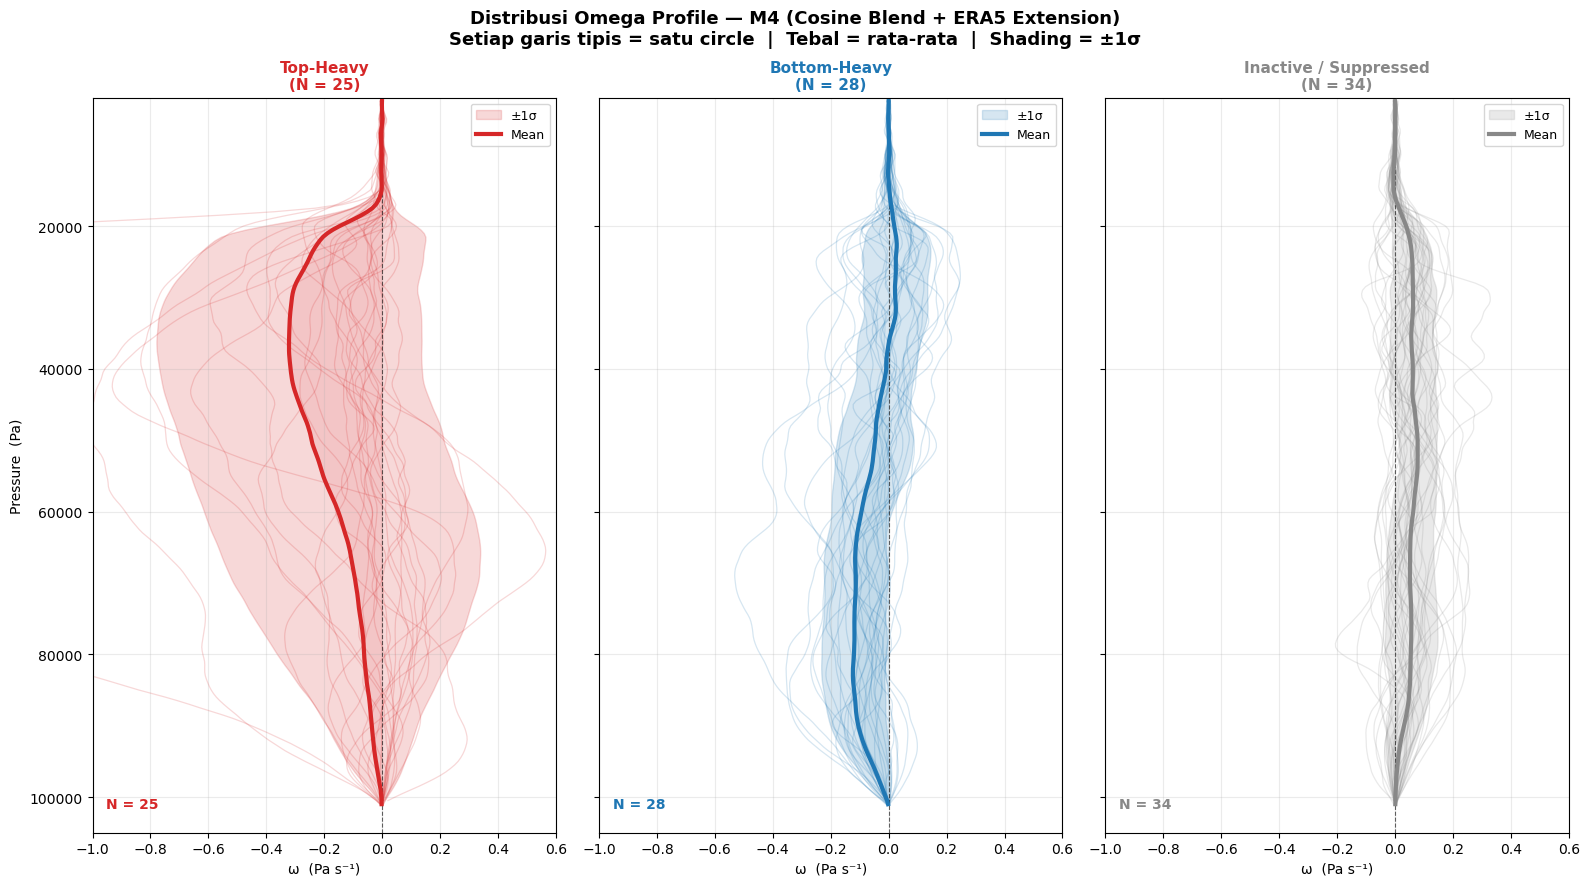

Saved → ../outputs/figures/omega_distribution_m4_density.png


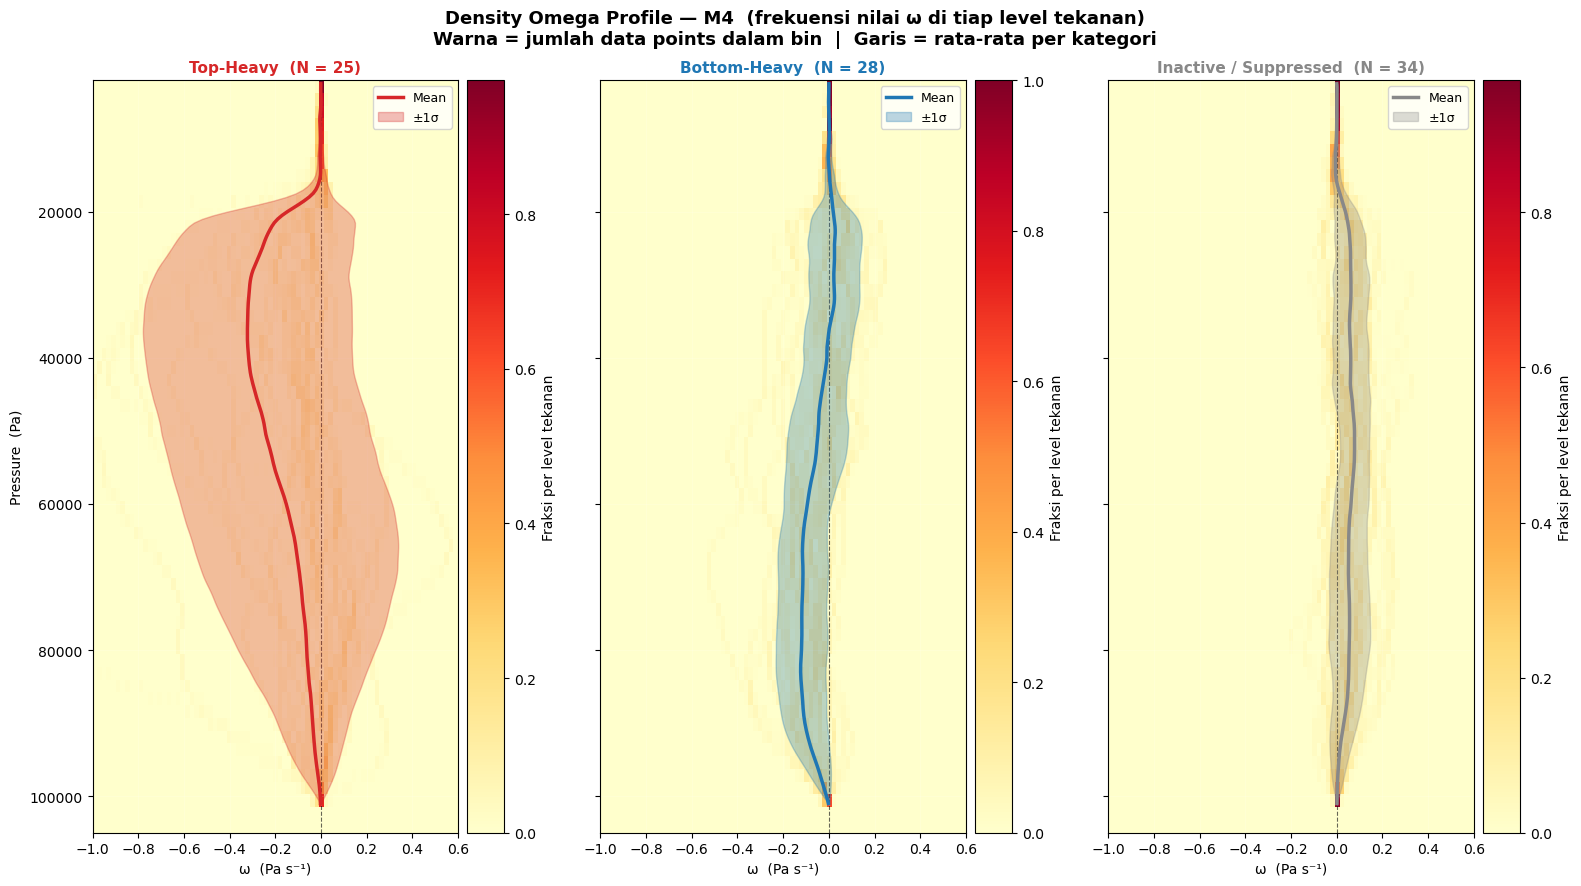

In [15]:
# ── Distribusi omega profile setelah M4 ramp function ────────────────────────
#
# Figure 1: Spaghetti + mean ± 1σ per kategori (TH, BH, Inactive)
# Figure 2: 2D density (heatmap omega vs pressure) per kategori
#
# Semua profil di-bin ke grid 500 Pa sebelum statistik dihitung.

import warnings
from pathlib import Path

BIN_PA   = 500.0
P_COMMON = np.arange(2000.0, 105500.0, BIN_PA)

GROUPS = {
    'Top-Heavy':           {'cats': ['Top-Heavy', 'Top-Heavy (Fully Ascending)'],    'color': '#d62728'},
    'Bottom-Heavy':        {'cats': ['Bottom-Heavy', 'Bottom-Heavy (Fully Ascending)'], 'color': '#1f77b4'},
    'Inactive / Suppressed': {'cats': ['Inactive / Suppressed'],                       'color': '#888888'},
}

def _bin(omega, p):
    valid = np.isfinite(omega) & np.isfinite(p)
    if valid.sum() < 3:
        return np.full(len(P_COMMON), np.nan)
    pv, ov = p[valid], omega[valid]
    edges  = np.arange(np.floor(pv.min()/BIN_PA)*BIN_PA,
                       np.ceil(pv.max()/BIN_PA)*BIN_PA + BIN_PA, BIN_PA)
    if len(edges) < 2:
        return np.full(len(P_COMMON), np.nan)
    osum, _ = np.histogram(pv, bins=edges, weights=ov)
    cnt,  _ = np.histogram(pv, bins=edges)
    pctr    = edges[:-1] + BIN_PA / 2
    res     = np.where(cnt > 0, osum / cnt, np.nan)
    has     = cnt > 0
    if has.sum() < 2:
        return np.full(len(P_COMMON), np.nan)
    return np.interp(P_COMMON, pctr[has], res[has], left=np.nan, right=np.nan)

# Pre-bin semua profil M4
binned_m4 = np.stack([_bin(omega_m4[i], p_m4[i]) for i in range(len(circles))])  # (89, nP)

# ─────────────────────────────────────────────────────────────────────────────
# Figure 1 — Spaghetti + Mean ± 1σ
# ─────────────────────────────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, 3, figsize=(16, 9), sharey=True)
fig1.suptitle(
    'Distribusi Omega Profile — M4 (Cosine Blend + ERA5 Extension)\n'
    'Setiap garis tipis = satu circle  |  Tebal = rata-rata  |  Shading = ±1σ',
    fontsize=13, fontweight='bold'
)

for ax, (label, cfg) in zip(axes1, GROUPS.items()):
    mask  = np.isin(cats, cfg['cats'])
    col   = cfg['color']
    n     = int(mask.sum())
    profs = binned_m4[mask]   # (n_circles_in_group, nP)

    # Spaghetti
    for prof in profs:
        v = np.isfinite(prof)
        if v.sum() > 3:
            ax.plot(prof[v], P_COMMON[v], color=col, alpha=0.18, lw=0.9, zorder=2)

    # Mean ± 1σ
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        mean = np.nanmean(profs, axis=0)
        std  = np.nanstd(profs,  axis=0)

    vm = np.isfinite(mean)
    ax.fill_betweenx(P_COMMON[vm], (mean-std)[vm], (mean+std)[vm],
                     alpha=0.18, color=col, zorder=1, label='±1σ')
    ax.plot(mean[vm], P_COMMON[vm], color=col, lw=3.0, zorder=3, label='Mean')

    # Shading kiri (ascending) untuk referensi visual
    ax.fill_betweenx(P_COMMON[vm], mean[vm], 0,
                     where=(mean[vm] < 0), alpha=0.10, color=col, zorder=0)

    ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.6)
    ax.set_xlim(-1.0, 0.6)
    ax.set_ylim(105000, 2000)
    ax.set_xlabel('ω  (Pa s⁻¹)', fontsize=10)
    ax.set_title(f'{label}\n(N = {n})', fontsize=11, fontweight='bold', color=col)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.25)
    ax.text(0.03, 0.03, f'N = {n}', transform=ax.transAxes,
            fontsize=10, color=col, fontweight='bold', va='bottom')

axes1[0].set_ylabel('Pressure  (Pa)', fontsize=10)
fig1.tight_layout()

out1 = Path('../outputs/figures/omega_distribution_m4_spaghetti.png')
fig1.savefig(out1, dpi=180, bbox_inches='tight')
print(f'Saved → {out1}')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figure 2 — 2D Density (heatmap omega vs pressure)
# ─────────────────────────────────────────────────────────────────────────────
OMEGA_BINS = np.linspace(-1.0, 0.6, 80)   # omega axis bins
P_BINS     = np.linspace(2000, 105000, 60) # pressure axis bins

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 9), sharey=True)
fig2.suptitle(
    'Density Omega Profile — M4  (frekuensi nilai ω di tiap level tekanan)\n'
    'Warna = jumlah data points dalam bin  |  Garis = rata-rata per kategori',
    fontsize=13, fontweight='bold'
)

for ax, (label, cfg) in zip(axes2, GROUPS.items()):
    mask = np.isin(cats, cfg['cats'])
    col  = cfg['color']
    n    = int(mask.sum())
    profs = binned_m4[mask]

    # Kumpulkan semua (omega, pressure) pairs dari profil yang valid
    all_o, all_p = [], []
    for prof in profs:
        v = np.isfinite(prof)
        if v.sum() > 3:
            all_o.extend(prof[v].tolist())
            all_p.extend(P_COMMON[v].tolist())

    if len(all_o) > 10:
        h, xedge, yedge = np.histogram2d(all_o, all_p,
                                          bins=[OMEGA_BINS, P_BINS])
        # Normalise per pressure row sehingga setiap level sumnya 1
        row_sum = h.sum(axis=0, keepdims=True)
        row_sum[row_sum == 0] = 1
        h_norm = h / row_sum

        pcm = ax.pcolormesh(
            xedge, yedge, h_norm.T,
            cmap='YlOrRd', shading='auto', zorder=1
        )
        plt.colorbar(pcm, ax=ax, label='Fraksi per level tekanan', pad=0.02)

    # Overlay mean
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        mean = np.nanmean(profs, axis=0)
        std  = np.nanstd(profs,  axis=0)
    vm = np.isfinite(mean)
    ax.plot(mean[vm], P_COMMON[vm], color=col, lw=2.5, zorder=4, label='Mean')
    ax.fill_betweenx(P_COMMON[vm], (mean-std)[vm], (mean+std)[vm],
                     alpha=0.30, color=col, zorder=3, label='±1σ')

    ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.6)
    ax.set_xlim(-1.0, 0.6)
    ax.set_ylim(105000, 2000)
    ax.set_xlabel('ω  (Pa s⁻¹)', fontsize=10)
    ax.set_title(f'{label}  (N = {n})', fontsize=11, fontweight='bold', color=col)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.15, color='white')

axes2[0].set_ylabel('Pressure  (Pa)', fontsize=10)
fig2.tight_layout()

out2 = Path('../outputs/figures/omega_distribution_m4_density.png')
fig2.savefig(out2, dpi=180, bbox_inches='tight')
print(f'Saved → {out2}')
plt.show()

Categorized 89 circles using M4 profiles  (R_threshold = 20.0)
category_omega_plane
Inactive / Suppressed             34
Bottom-Heavy                      22
Top-Heavy                         16
Top-Heavy (Fully Ascending)        8
Bottom-Heavy (Fully Ascending)     7
Missing Data                       2
Saved → ../outputs/figures/omega_plane_category_distribution_m4.png


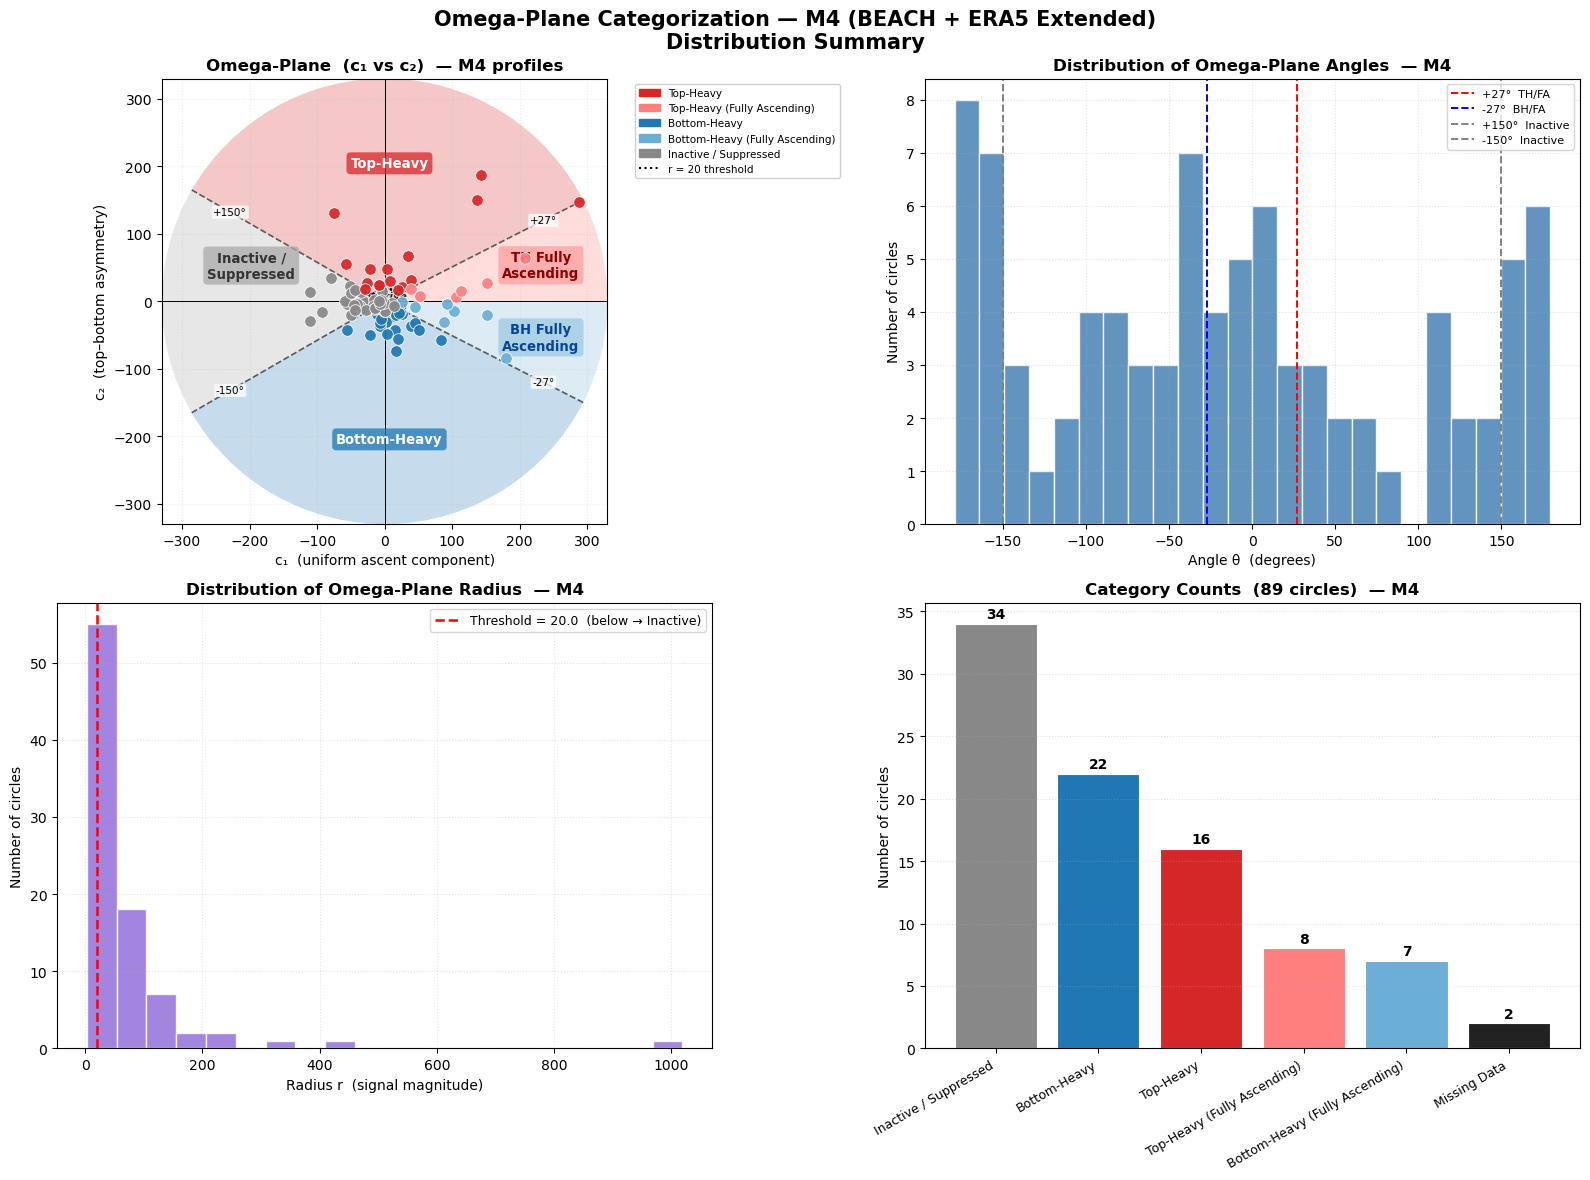

In [16]:
# ── Categorization Distribution Charts — using M4 ERA5-extended profiles ─────
# Recreates the 4-panel summary using omega_m4 + p_m4 (full column to ~20 hPa)
# instead of raw BEACH omega (which stops at ~150–245 hPa).

from pathlib import Path
from matplotlib.patches import Wedge, Circle
import matplotlib.patches as mpatches

from scripts.categorize_omega import categorise_all, R_THRESHOLD

# Wrap M4 arrays into a minimal dataset that categorise_all can read.
# categorise_all reads ds['omega'], ds['p_mean'], ds['circle_time'].
ds_m4_wrap = xr.Dataset(
    {
        'omega':       xr.DataArray(omega_m4, dims=('circle', 'm4_level'),
                                    coords={'circle': ds['circle']}),
        'p_mean':      xr.DataArray(p_m4,     dims=('circle', 'm4_level'),
                                    coords={'circle': ds['circle']}),
        'circle_time': ds['circle_time'],
    }
)

df       = categorise_all(ds_m4_wrap, R_THRESHOLD)
df_valid = df[df['category_omega_plane'] != 'Missing Data'].copy()
print(f'Categorized {len(df)} circles using M4 profiles  (R_threshold = {R_THRESHOLD})')
print(df['category_omega_plane'].value_counts().to_string())

CATEGORY_COLORS = {
    'Top-Heavy':                      '#d62728',
    'Top-Heavy (Fully Ascending)':    '#ff7f7f',
    'Bottom-Heavy':                   '#1f77b4',
    'Bottom-Heavy (Fully Ascending)': '#6baed6',
    'Inactive / Suppressed':          '#888888',
    'Missing Data':                   '#222222',
}
BOUNDARIES_DEG = [27, -27, 150, -150]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Omega-Plane Categorization — M4 (BEACH + ERA5 Extended)\nDistribution Summary',
             fontsize=15, fontweight='bold')

# ── Panel 1: Omega-plane scatter ─────────────────────────────────────────────
ax = axes[0, 0]
r_95   = np.percentile(df_valid['r_mag'], 95)
r_plot = max(r_95 * 1.55, R_THRESHOLD * 5)
ax.set_xlim(-r_plot, r_plot); ax.set_ylim(-r_plot, r_plot); ax.set_aspect('equal')

WEDGE_SPECS = [
    ( 27,  150, '#d62728', 0.25, 'Top-Heavy',               88,  0.62, 'white'),
    (  0,   27, '#ff9f9f', 0.35, 'TH Fully\nAscending',     13,  0.72, '#8b0000'),
    ( -27,   0, '#9ecae1', 0.35, 'BH Fully\nAscending',    -13,  0.72, '#084594'),
    (-150, -27, '#1f77b4', 0.25, 'Bottom-Heavy',            -88,  0.62, 'white'),
    ( 150, 180, '#aaaaaa', 0.28, 'Inactive /\nSuppressed',  165,  0.62, '#333333'),
    (-180,-150, '#aaaaaa', 0.28, '',                        -165,  0.62, '#333333'),
]
for t1, t2, col, alpha, lbl, lang, lfrac, tcol in WEDGE_SPECS:
    ax.add_patch(Wedge((0, 0), r_plot, t1, t2,
                       width=r_plot - R_THRESHOLD,
                       facecolor=col, alpha=alpha, edgecolor='none', zorder=1))
    if lbl:
        lx = r_plot * lfrac * np.cos(np.radians(lang))
        ly = r_plot * lfrac * np.sin(np.radians(lang))
        ax.text(lx, ly, lbl, ha='center', va='center',
                fontsize=9.5, fontweight='bold', color=tcol, zorder=3,
                bbox=dict(boxstyle='round,pad=0.3', fc=col, alpha=0.75, ec='none'))

ax.add_patch(Circle((0, 0), R_THRESHOLD,
                    facecolor='#aaaaaa', alpha=0.40,
                    edgecolor='#555555', lw=1.2, zorder=2))
ax.text(0, 0, f'Inactive\n(r < {R_THRESHOLD:.0f})', ha='center', va='center',
        fontsize=7.5, color='#222222', fontstyle='italic', fontweight='bold', zorder=4)

for deg in BOUNDARIES_DEG:
    rad = np.radians(deg)
    ax.plot([R_THRESHOLD * np.cos(rad), r_plot * np.cos(rad)],
            [R_THRESHOLD * np.sin(rad), r_plot * np.sin(rad)],
            color='black', lw=1.2, ls='--', alpha=0.60, zorder=2)
    lx = r_plot * 0.80 * np.cos(rad); ly = r_plot * 0.80 * np.sin(rad)
    ax.text(lx, ly, f'{deg:+d}°', ha='center', va='center', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.75, ec='none'), zorder=4)

th = np.linspace(0, 2 * np.pi, 300)
ax.plot(R_THRESHOLD * np.cos(th), R_THRESHOLD * np.sin(th),
        color='black', lw=1.8, ls=':', zorder=3)

for cat, grp in df_valid.groupby('category_omega_plane'):
    ax.scatter(grp['c1'], grp['c2'],
               color=CATEGORY_COLORS.get(cat, 'gray'),
               edgecolors='white', linewidths=0.6, s=70, alpha=0.92, zorder=5)

ax.axhline(0, color='black', lw=0.7, zorder=2)
ax.axvline(0, color='black', lw=0.7, zorder=2)
ax.set_xlabel('c₁  (uniform ascent component)', fontsize=10)
ax.set_ylabel('c₂  (top–bottom asymmetry)', fontsize=10)
ax.set_title('Omega-Plane  (c₁ vs c₂)  — M4 profiles', fontsize=12, fontweight='bold')
ax.legend(
    fontsize=7.5, loc='upper left', bbox_to_anchor=(1.05, 1), framealpha=0.92,
    handles=[mpatches.Patch(color=v, label=k)
             for k, v in CATEGORY_COLORS.items() if k != 'Missing Data']
    + [plt.Line2D([0], [0], color='black', lw=1.5, ls=':',
                  label=f'r = {R_THRESHOLD:.0f} threshold')]
)
ax.grid(True, ls=':', alpha=0.25, zorder=0)

# ── Panel 2: Angle histogram ─────────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(df_valid['angle_deg'].dropna(), bins=24,
        color='steelblue', edgecolor='white', alpha=0.85)
for deg, (lbl, col) in {27: ('TH/FA', 'red'), -27: ('BH/FA', 'blue'),
                         150: ('Inactive', 'gray'), -150: ('Inactive', 'gray')}.items():
    ax.axvline(deg, color=col, ls='--', lw=1.4, label=f'{deg:+d}°  {lbl}')
ax.set_xlabel('Angle θ  (degrees)', fontsize=10)
ax.set_ylabel('Number of circles', fontsize=10)
ax.set_title('Distribution of Omega-Plane Angles  — M4', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, ls=':', alpha=0.35)

# ── Panel 3: Radius histogram ────────────────────────────────────────────────
ax = axes[1, 0]
ax.hist(df_valid['r_mag'].dropna(), bins=20,
        color='mediumpurple', edgecolor='white', alpha=0.85)
ax.axvline(R_THRESHOLD, color='red', ls='--', lw=1.8,
           label=f'Threshold = {R_THRESHOLD}  (below → Inactive)')
ax.set_xlabel('Radius r  (signal magnitude)', fontsize=10)
ax.set_ylabel('Number of circles', fontsize=10)
ax.set_title('Distribution of Omega-Plane Radius  — M4', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, ls=':', alpha=0.35)

# ── Panel 4: Category bar chart ──────────────────────────────────────────────
ax = axes[1, 1]
cat_counts = df['category_omega_plane'].value_counts()
bars = ax.bar(range(len(cat_counts)), cat_counts.values,
              color=[CATEGORY_COLORS.get(c, 'gray') for c in cat_counts.index],
              edgecolor='white', linewidth=0.8)
ax.set_xticks(range(len(cat_counts)))
ax.set_xticklabels(cat_counts.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Number of circles', fontsize=10)
ax.set_title(f'Category Counts  ({len(df)} circles)  — M4', fontsize=12, fontweight='bold')
for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(True, axis='y', ls=':', alpha=0.35)

plt.tight_layout()
out = Path('../outputs/figures/omega_plane_category_distribution_m4.png')
fig.savefig(out, dpi=180, bbox_inches='tight')
print(f'Saved → {out}')
plt.show()